# NFXP — Empirical Application

**Oliver Ovdal Eiberg Jørgensen & Solveig Røndal-Liniger** — Dynamic Programming, Spring 2026

---

Estimerer den strukturelle model på Netto-scannerpanelet.  
Denne notebook normaliserer **$\alpha_1=0$** (Brand 1 er reference) og estimerer **$\alpha_2$** relativt til Brand 1, **$\gamma$** (fælles marginal prisaversion), **$\beta^{dep}$** (deprecieringsrate) og **$\beta^{sc}$** (symmetriske switching costs) simultant.

**Parametre:**
$$\theta = [\alpha_2,\; \gamma,\; \beta^{dep},\; \beta^{sc}],\qquad \alpha_1=0$$

- $\alpha_1 = 0$ er normaliseringen (Brand 1 er referencen)
- $\alpha_2$ er Brand 2-præference relativt til Brand 1
- $\beta^{sc}$ er symmetrisk: samme omkostning uanset hvilken retning der skiftes

## 1. Import

In [463]:
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar, minimize
from scipy.stats import norm, chi2
import matplotlib.pyplot as plt

## 2. Model-dimensioner og konstanter

In [464]:
J        = 2       # antal brands
D_MAX    = 25      # durationsgrænse (uger siden sidst køb); 0 % capping i data
DELTA    = 0.95    # diskonteringsfaktor
N_CHOICES = J + 1  # {0=ingen køb, 1=brand 1, 2=brand 2}

EMPIRICAL_BRANDS        = [1, 2]
EMPIRICAL_PRICE_COLUMNS = {1: "Brand_1_price", 2: "Brand_2_price"}

# VFI-tolerancer
VFI_TOL     = 1e-10
VFI_MAXITER = 2_000
TRANS_SMOOTH = 1e-3   # Laplace-smoothing til overgangsmatrix

# ── Promotionstilstande ───────────────────────────────────────────────────────
# promo_states[s] = binær vektor over brands: 1 = kampagne aktiv
promo_states = np.array(
    [[(s >> j) & 1 for j in range(J)] for s in range(2 ** J)], dtype=int
)
N_PROMO = len(promo_states)

print(f"J={J}, D_MAX={D_MAX}, N_CHOICES={N_CHOICES}, N_PROMO={N_PROMO}")
print("Promotionstilstande:", promo_states)

J=2, D_MAX=25, N_CHOICES=3, N_PROMO=4
Promotionstilstande: [[0 0]
 [1 0]
 [0 1]
 [1 1]]


## 3. Indlæs data

In [465]:
import pandas as pd
import numpy as np

# ── Datapaths ────────────────────────────────────────────────────────────────
SCANNER_DATA     = "/Users/solveigroendalliniger/Desktop/netto_df.csv"
PRICE_PROMO_DATA = "/Users/solveigroendalliniger/Desktop/Price_Promo.xlsx"
# ────────────────────────────────────────────────────────────────────────────


# ── Load scanner panel ──────────────────────────────────────────────────────
netto_df = pd.read_csv(SCANNER_DATA)

# Clean column names
netto_df.columns = netto_df.columns.astype(str).str.strip()

# Tjek nødvendige kolonner
scanner_required_columns = [
    "week_num",
    "Brand",
    "Price",
    "Customer_ID",
]

missing_scanner_columns = [
    col for col in scanner_required_columns
    if col not in netto_df.columns
]

if missing_scanner_columns:
    raise ValueError(
        f"Disse kolonner mangler i netto_df: {missing_scanner_columns}\n"
        f"Kolonner i netto_df er: {netto_df.columns.tolist()}"
    )

# Fjern uge 53
netto_df = netto_df[netto_df["week_num"] != 53].copy()

# Datatyper
netto_df["Brand"] = netto_df["Brand"].astype(str)

netto_df["Price"] = pd.to_numeric(
    netto_df["Price"],
    errors="coerce"
).round(1)

netto_df["Customer_ID"] = pd.to_numeric(
    netto_df["Customer_ID"],
    errors="coerce"
).astype("Int64")

netto_df["week_num"] = pd.to_numeric(
    netto_df["week_num"],
    errors="coerce"
).astype("Int64")

netto_df["brand_id"] = pd.to_numeric(
    netto_df["Brand"],
    errors="coerce"
).fillna(0).astype(int)


# ── Load price/promo Excel ──────────────────────────────────────────────────
price_promo_workbook = pd.ExcelFile(PRICE_PROMO_DATA)

print("Sheets in Price_Promo.xlsx:")
print(price_promo_workbook.sheet_names)

# Brug tredje sheet
price_promo_sheet_name = price_promo_workbook.sheet_names[2]
print(f"\nUsing sheet: {price_promo_sheet_name}")

price_promo_df = pd.read_excel(
    price_promo_workbook,
    sheet_name=price_promo_sheet_name
)

# Clean column names
price_promo_df.columns = price_promo_df.columns.astype(str).str.strip()


# ── Required price/promo columns ─────────────────────────────────────────────
price_promo_required_columns = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Promo_Brand_1",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Promo_Brand_2",
]

missing_price_columns = [
    col for col in price_promo_required_columns
    if col not in price_promo_df.columns
]

if missing_price_columns:
    raise ValueError(
        f"Disse kolonner mangler i price_promo_df: {missing_price_columns}\n"
        f"Kolonner i arket er: {price_promo_df.columns.tolist()}"
    )

price_promo_df = price_promo_df[price_promo_required_columns].copy()


# ── Clean price/promo data ──────────────────────────────────────────────────
for col in price_promo_required_columns:
    price_promo_df[col] = pd.to_numeric(
        price_promo_df[col],
        errors="coerce"
    )

price_promo_df = price_promo_df.dropna(subset=["WeekNum"]).copy()
price_promo_df["WeekNum"] = price_promo_df["WeekNum"].astype(int)

# Tjek dubletter i uge
if price_promo_df["WeekNum"].duplicated().any():
    duplicated_weeks = (
        price_promo_df.loc[
            price_promo_df["WeekNum"].duplicated(),
            "WeekNum"
        ]
        .unique()
    )

    raise ValueError(
        f"Der er dubletter i WeekNum i price_promo_df: {duplicated_weeks}"
    )


# ── Construct binary offered prices directly ────────────────────────────────
# Pris = RRP hvis ingen kampagne
# Pris = gennemsnitlig kampagnepris hvis kampagne

# Promo skal være 0/1
price_promo_df["Promo_Brand_1"] = (
    price_promo_df["Promo_Brand_1"]
    .fillna(0)
    .astype(int)
)

price_promo_df["Promo_Brand_2"] = (
    price_promo_df["Promo_Brand_2"]
    .fillna(0)
    .astype(int)
)


# Brand 1: gennemsnitlig kampagnepris
mean_discount_brand_1 = price_promo_df.loc[
    (price_promo_df["Promo_Brand_1"] == 1) &
    (price_promo_df["Discount_Brand_1"].notna()),
    "Discount_Brand_1"
].mean()

if not np.isfinite(mean_discount_brand_1):
    mean_discount_brand_1 = price_promo_df["Discount_Brand_1"].mean()

if not np.isfinite(mean_discount_brand_1):
    mean_discount_brand_1 = price_promo_df["RRP_Brand_1"].median()


# Brand 2: gennemsnitlig kampagnepris
mean_discount_brand_2 = price_promo_df.loc[
    (price_promo_df["Promo_Brand_2"] == 1) &
    (price_promo_df["Discount_Brand_2"].notna()),
    "Discount_Brand_2"
].mean()

if not np.isfinite(mean_discount_brand_2):
    mean_discount_brand_2 = price_promo_df["Discount_Brand_2"].mean()

if not np.isfinite(mean_discount_brand_2):
    mean_discount_brand_2 = price_promo_df["RRP_Brand_2"].median()


# Gem gennemsnitlige kampagnepriser
price_promo_df["Mean_Discount_Brand_1"] = mean_discount_brand_1
price_promo_df["Mean_Discount_Brand_2"] = mean_discount_brand_2


# Lav de pris-kolonner, som merge skal bruge
price_promo_df["Brand_1_price"] = np.where(
    price_promo_df["Promo_Brand_1"] == 1,
    mean_discount_brand_1,
    price_promo_df["RRP_Brand_1"]
)

price_promo_df["Brand_2_price"] = np.where(
    price_promo_df["Promo_Brand_2"] == 1,
    mean_discount_brand_2,
    price_promo_df["RRP_Brand_2"]
)


# ── Safety check før merge ──────────────────────────────────────────────────
price_promo_merge_columns = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Mean_Discount_Brand_1",
    "Promo_Brand_1",
    "Brand_1_price",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Mean_Discount_Brand_2",
    "Promo_Brand_2",
    "Brand_2_price",
]

missing_merge_columns = [
    col for col in price_promo_merge_columns
    if col not in price_promo_df.columns
]

if missing_merge_columns:
    raise ValueError(
        f"Disse merge-kolonner mangler i price_promo_df: {missing_merge_columns}\n"
        f"Kolonner i price_promo_df er: {price_promo_df.columns.tolist()}"
    )


# ── Print price support ─────────────────────────────────────────────────────
empirical_binary_price_summary = pd.DataFrame(
    [
        {
            "Brand": 1,
            "RRP median": price_promo_df["RRP_Brand_1"].median(),
            "Mean sale price": mean_discount_brand_1,
            "Promo weeks": int(price_promo_df["Promo_Brand_1"].sum()),
        },
        {
            "Brand": 2,
            "RRP median": price_promo_df["RRP_Brand_2"].median(),
            "Mean sale price": mean_discount_brand_2,
            "Promo weeks": int(price_promo_df["Promo_Brand_2"].sum()),
        },
    ]
)

print("\nBinary empirical price support:")
print(
    empirical_binary_price_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)


print("\nPrice/promo preview:")
print(
    price_promo_df[
        [
            "WeekNum",
            "RRP_Brand_1",
            "Promo_Brand_1",
            "Brand_1_price",
            "RRP_Brand_2",
            "Promo_Brand_2",
            "Brand_2_price",
        ]
    ]
    .head(10)
)
# ── Fjern gamle price/promo-kolonner fra netto_df før merge ─────────────────
old_price_promo_cols = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Mean_Discount_Brand_1",
    "Promo_Brand_1",
    "Brand_1_price",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Mean_Discount_Brand_2",
    "Promo_Brand_2",
    "Brand_2_price",
]

# Fjern også evt. _x og _y kolonner fra tidligere merges
old_price_promo_cols_extended = old_price_promo_cols.copy()

for col in old_price_promo_cols:
    old_price_promo_cols_extended.append(f"{col}_x")
    old_price_promo_cols_extended.append(f"{col}_y")

netto_df = netto_df.drop(
    columns=[col for col in old_price_promo_cols_extended if col in netto_df.columns]
)

# ── Merge weekly price/promo data onto scanner panel ────────────────────────
netto_df = netto_df.merge(
    price_promo_df[price_promo_merge_columns],
    left_on="week_num",
    right_on="WeekNum",
    how="left",
    validate="many_to_one"
)


# ── Keep only rows with both alternative prices available ───────────────────
netto_df = netto_df.loc[
    netto_df["Brand_1_price"].notna() &
    netto_df["Brand_2_price"].notna()
].copy()


# ── Final check ─────────────────────────────────────────────────────────────
print(
    f"\nPanel: {netto_df['Customer_ID'].nunique():,} husstande, "
    f"{netto_df['week_num'].nunique()} uger"
)

print("\nFirst rows:")
display(netto_df.head())

Sheets in Price_Promo.xlsx:
['_com.sap.ip.bi.xl.hiddensheet', 'Sheet1', 'Sheet2', 'Sheet3']

Using sheet: Sheet2

Binary empirical price support:
 Brand  RRP median  Mean sale price  Promo weeks
     1      24.950            9.842           10
     2      11.950            9.993            6

Price/promo preview:
   WeekNum  RRP_Brand_1  Promo_Brand_1  Brand_1_price  RRP_Brand_2  \
0        1        24.95              0      24.950000        11.95   
1        2        24.95              0      24.950000        11.95   
2        3        24.95              0      24.950000        11.95   
3        4        24.95              0      24.950000        11.95   
4        5        24.95              0      24.950000        11.95   
5        6        24.95              0      24.950000        11.95   
6        7        24.95              0      24.950000        11.95   
7        8        24.95              1       9.842316        11.95   
8        9        24.95              0      24.950000  

,Unnamed: 0,Customer_ID,week_num,y,Brand,Quantity,promo_flag,Price,last_purchase_week,duration,...,RRP_Brand_1,Discount_Brand_1,Mean_Discount_Brand_1,Promo_Brand_1,Brand_1_price,RRP_Brand_2,Discount_Brand_2,Mean_Discount_Brand_2,Promo_Brand_2,Brand_2_price
0,1,1,1,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
1,2,1,2,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
2,3,1,3,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
3,4,1,4,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
4,5,1,5,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95


## 4. Empirisk prisproces

Estimér den ugentlige overgangsmatrix for kampagnetilstande og median-priser per tilstand fra dataene.

In [466]:
def empirical_promo_idx(frame: pd.DataFrame) -> np.ndarray:
    """Mappe Promo_Brand_1/2 til indeks i promo_states."""
    mat = frame[[f"Promo_Brand_{b}" for b in EMPIRICAL_BRANDS]].fillna(0).astype(int).to_numpy()
    return mat @ (2 ** np.arange(J))


def build_weekly_state_table(data: pd.DataFrame) -> pd.DataFrame:
    weekly = (
        data[["week_num", "Brand_1_price", "Brand_2_price", "Promo_Brand_1", "Promo_Brand_2"]]
        .dropna().drop_duplicates().sort_values("week_num").reset_index(drop=True)
    )
    weekly["promo_idx"] = empirical_promo_idx(weekly)
    return weekly


def estimate_promo_transition(weekly: pd.DataFrame, smoothing=TRANS_SMOOTH) -> np.ndarray:
    idx = weekly["promo_idx"].to_numpy(dtype=int)
    counts = np.full((N_PROMO, N_PROMO), smoothing)
    np.add.at(counts, (idx[:-1], idx[1:]), 1.0)
    return counts / counts.sum(axis=1, keepdims=True)


def build_price_by_promo(weekly: pd.DataFrame) -> np.ndarray:
    pbp = np.full((N_PROMO, J), np.nan)
    for s in range(N_PROMO):
        rows = weekly.loc[weekly["promo_idx"] == s]
        if len(rows) == 0:
            continue
        for b_idx, b in enumerate(EMPIRICAL_BRANDS):
            pbp[s, b_idx] = rows[EMPIRICAL_PRICE_COLUMNS[b]].median()
    # Fallback for unobserverede tilstande
    for s, pvec in enumerate(promo_states):
        for b_idx, b in enumerate(EMPIRICAL_BRANDS):
            if np.isfinite(pbp[s, b_idx]):
                continue
            fb = weekly.loc[
                weekly[f"Promo_Brand_{b}"].astype(int) == int(pvec[b_idx]),
                EMPIRICAL_PRICE_COLUMNS[b]
            ].median()
            pbp[s, b_idx] = fb if np.isfinite(fb) else weekly[EMPIRICAL_PRICE_COLUMNS[b]].median()
    return pbp


weekly_state     = build_weekly_state_table(netto_df)
PROMO_TRANS      = estimate_promo_transition(weekly_state)
PRICE_BY_PROMO   = build_price_by_promo(weekly_state)

lbl = [f"e={tuple(int(v) for v in r)}" for r in promo_states]
print("Priser per kampagnetilstand:")
print(pd.DataFrame(PRICE_BY_PROMO, index=lbl, columns=["Brand 1", "Brand 2"]).to_string(float_format=lambda x: f"{x:.3f}"))
print("\nEstimeret ugentlig overgangsmatrix:")
print(pd.DataFrame(PROMO_TRANS, index=lbl, columns=lbl).to_string(float_format=lambda x: f"{x:.3f}"))

Priser per kampagnetilstand:
          Brand 1  Brand 2
e=(0, 0)   24.950   11.950
e=(1, 0)    9.842   11.950
e=(0, 1)   24.950    9.993
e=(1, 1)    9.842    9.993

Estimeret ugentlig overgangsmatrix:
          e=(0, 0)  e=(1, 0)  e=(0, 1)  e=(1, 1)
e=(0, 0)     0.722     0.167     0.083     0.028
e=(1, 0)     0.666     0.222     0.111     0.000
e=(0, 1)     0.600     0.200     0.200     0.000
e=(1, 1)     0.997     0.001     0.001     0.001


## 5. Panelforberedelse

Rekonstruér tilstandsvariablerne $( \\ell_{it}, d_{it}, e_t )$ fra det observerede panel og aggregér til state-choice counts.

In [467]:
def prepare_panel(data: pd.DataFrame, d_max: int = D_MAX):
    panel = data.sort_values(["Customer_ID", "week_num"]).copy()
    panel["choice"] = panel["brand_id"].where(panel["brand_id"].isin(EMPIRICAL_BRANDS), 0).astype(int)
    panel["purchase_brand"] = panel["choice"].where(panel["choice"] > 0)
    panel["purchase_week"]  = panel["week_num"].where(panel["choice"] > 0)

    grp = panel.groupby("Customer_ID", sort=False)
    panel["last_brand_incl"] = grp["purchase_brand"].ffill()
    panel["last_week_incl"]  = grp["purchase_week"].ffill()
    panel["pre_last_brand"]  = grp["last_brand_incl"].shift(1)
    panel["pre_last_week"]   = grp["last_week_incl"].shift(1)
    panel["pre_dur_weeks"]   = panel["week_num"] - panel["pre_last_week"]

    usable = panel.loc[
        panel["pre_last_brand"].isin(EMPIRICAL_BRANDS)
        & panel["pre_dur_weeks"].notna()
        & panel["Promo_Brand_1"].notna()
        & panel["Promo_Brand_2"].notna()
    ].copy()

    usable["Y"]     = usable["choice"].astype(int)
    usable["L"]     = usable["pre_last_brand"].astype(int)
    usable["D"]     = np.clip(usable["pre_dur_weeks"].to_numpy(dtype=float), 1, d_max).astype(int)
    usable["E_IDX"] = empirical_promo_idx(usable)

    counts = np.zeros((J, d_max + 1, N_PROMO, N_CHOICES), dtype=float)
    np.add.at(
        counts,
        (usable["L"].to_numpy() - 1, usable["D"].to_numpy(),
         usable["E_IDX"].to_numpy(), usable["Y"].to_numpy()),
        1.0,
    )
    return usable, counts


panel_df, OBS_COUNTS = prepare_panel(netto_df)
N_OBS = int(OBS_COUNTS.sum())

choice_shares = OBS_COUNTS.sum(axis=(0, 1, 2)) / N_OBS
print(f"Observationer (alle): {N_OBS:,}")
print(f"  Ingen køb: {choice_shares[0]:.1%}")
for j in range(1, J + 1):
    print(f"  Brand {j}:    {choice_shares[j]:.1%}")
print(f"  Duration cap: {D_MAX}  |  Cappede: {(panel_df['D'] == D_MAX).mean():.1%}")

Observationer (alle): 1,697,631
  Ingen køb: 84.8%
  Brand 1:    3.4%
  Brand 2:    11.8%
  Duration cap: 25  |  Cappede: 1.5%


## 5b. Reduced-form duration-diagnostic

Tjek om købsraten varierer systematisk med duration. Det er den centrale variation, der identificerer $\beta^{dep}$.

Reduced-form købsrater efter duration:
 D    obs purchase_rate brand_1_rate brand_2_rate
 1 296373        0.2035       0.0267       0.1768
 2 232654        0.1675       0.0225       0.1450
 3 191236        0.1728       0.0385       0.1343
 4 156200        0.1403       0.0276       0.1127
 5 132474        0.1771       0.0827       0.0943
 6 107492        0.1148       0.0178       0.0970
 7  93797        0.1140       0.0185       0.0955
 8  81823        0.1330       0.0474       0.0856
 9  62107        0.1043       0.0209       0.0834
10  54662        0.1521       0.0730       0.0791
11  45720        0.1096       0.0179       0.0917
12  35799        0.1049       0.0214       0.0835
13  31355        0.1367       0.0588       0.0779
14  26496        0.1006       0.0237       0.0769
15  22719        0.1268       0.0552       0.0716
16  18995        0.1200       0.0262       0.0938
17  16205        0.0923       0.0226       0.0697
18  14447        0.1093       0.0415       0.0678
19  12532  

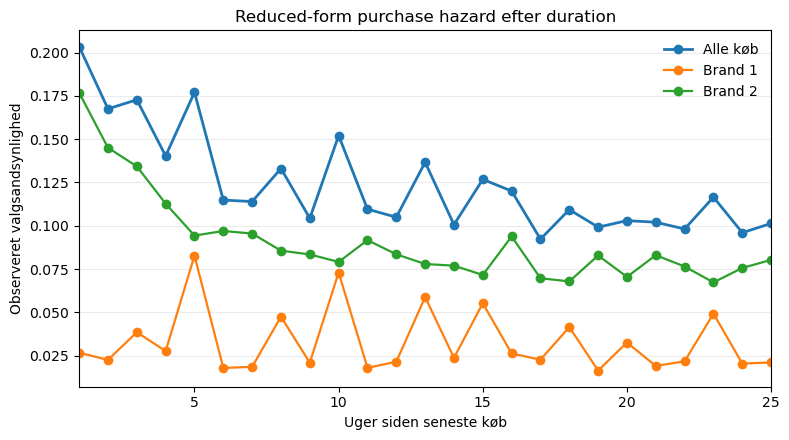

In [468]:
duration_summary = (
    panel_df.assign(
        purchase=(panel_df["Y"] > 0).astype(int),
        brand_1=(panel_df["Y"] == 1).astype(int),
        brand_2=(panel_df["Y"] == 2).astype(int),
    )
    .groupby("D")
    .agg(
        obs=("Y", "size"),
        purchase_rate=("purchase", "mean"),
        brand_1_rate=("brand_1", "mean"),
        brand_2_rate=("brand_2", "mean"),
    )
    .reset_index()
)

print("Reduced-form købsrater efter duration:")
print(
    duration_summary.head(20).to_string(
        index=False,
        formatters={
            "purchase_rate": lambda x: f"{x:.4f}",
            "brand_1_rate": lambda x: f"{x:.4f}",
            "brand_2_rate": lambda x: f"{x:.4f}",
        },
    )
)
if len(duration_summary) > 20:
    print(f"... viser 20 af {len(duration_summary)} duration-værdier")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(duration_summary["D"], duration_summary["purchase_rate"], marker="o", lw=2, label="Alle køb")
ax.plot(duration_summary["D"], duration_summary["brand_1_rate"], marker="o", lw=1.6, label="Brand 1")
ax.plot(duration_summary["D"], duration_summary["brand_2_rate"], marker="o", lw=1.6, label="Brand 2")
ax.set_xlim(1, D_MAX)
ax.set_xlabel("Uger siden seneste køb")
ax.set_ylabel("Observeret valgsandsynlighed")
ax.set_title(r"Reduced-form purchase hazard efter duration")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("nfxp_empirical_duration_hazard.pdf", bbox_inches="tight")
plt.show()

## 6. Vectoriseret empirisk VFI og CCPs

Samme logik som i MC-notebooken, men med estimeret `PROMO_TRANS` og observerede `PRICE_BY_PROMO` fra data. Promotions er igen en state variable i value functionen.

$\alpha_1 = 0$ er normaliseringen (Brand 1 er referencen). $\alpha_2$ estimeres relativt til Brand 1.

$$Q_0(\ell, d, e) = \alpha_\ell - \beta^{dep}_\ell \cdot d + \delta \cdot EV(\ell, d+1, e')$$
$$Q_j(\ell, d, e) = \alpha_j - \gamma \cdot p_j(e) - \beta^{sc}_{\ell j} + \delta \cdot EV(j, 1, e')$$

In [469]:
def solve_vfi(
    alpha: np.ndarray,
    gamma: np.ndarray,
    beta_sc: np.ndarray,
    beta_dep: np.ndarray,
    tol: float = VFI_TOL,
    max_iter: int = VFI_MAXITER,
) -> np.ndarray:
    """
    Vectoriseret VFI. V shape: (J, D_MAX+1, N_PROMO).
    alpha_1 = 0 er normaliseringen. alpha = [alpha_1, alpha_2].
    Q_0[l,d,e] = alpha[l] - beta_dep[l]*d + delta*EV[l, min(d+1,D_MAX), e']
    Q_j[l,d,e] = alpha[j] - gamma*p_j[e] - beta_sc[l,j] + delta*EV[j, 1, e']
    """
    dur_idx  = np.arange(D_MAX + 1)
    duration = dur_idx.astype(float)
    next_dur = np.minimum(dur_idx + 1, D_MAX)

    # No-purchase nyttekomponent (J, D_MAX+1) — alpha_1 = 0 normalisering
    no_purch = alpha[:, None] - beta_dep[:, None] * duration[None, :]

    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    V = np.zeros((J, D_MAX + 1, N_PROMO))

    for _ in range(max_iter):
        EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T).reshape(J, D_MAX + 1, N_PROMO)

        # Ingen køb: næste tilstand er (ℓ, min(d+1, D_MAX))
        Q[..., 0] = no_purch[:, :, None] + DELTA * EV[:, next_dur, :]

        # Køb brand j: næste tilstand er (j, d=1), dvs. første uge efter køb
        for j in range(J):
            Q[..., j + 1] = (
                alpha[j]
                - gamma * PRICE_BY_PROMO[:, j][None, None, :]
                - beta_sc[:, j][:, None, None]
                + DELTA * EV[j, 1, :][None, None, :]
            )

        q_max = Q.max(axis=3)
        V_new = q_max + np.log(np.exp(Q - q_max[..., None]).sum(axis=3))
        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

    return V


def compute_ccps(
    V: np.ndarray,
    alpha: np.ndarray,
    gamma: np.ndarray,
    beta_sc: np.ndarray,
    beta_dep: np.ndarray,
) -> np.ndarray:
    """CCP'er. P shape: (J, D_MAX+1, N_PROMO, N_CHOICES). alpha_1 = 0 normalisering."""
    dur_idx  = np.arange(D_MAX + 1)
    duration = dur_idx.astype(float)
    next_dur = np.minimum(dur_idx + 1, D_MAX)

    no_purch = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T).reshape(J, D_MAX + 1, N_PROMO)
    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    Q[..., 0] = no_purch[:, :, None] + DELTA * EV[:, next_dur, :]
    for j in range(J):
        Q[..., j + 1] = (
            alpha[j]
            - gamma * PRICE_BY_PROMO[:, j][None, None, :]
            - beta_sc[:, j][:, None, None]
            + DELTA * EV[j, 1, :][None, None, :]
        )

    w = np.exp(Q - Q.max(axis=3, keepdims=True))
    return w / w.sum(axis=3, keepdims=True)


def log_lik(counts: np.ndarray, P: np.ndarray) -> float:
    return float(np.sum(counts * np.log(np.maximum(P, 1e-300))))


print("VFI og CCP-funktioner klar (alpha_1 = 0, alpha_2 relativ til Brand 1).")

VFI og CCP-funktioner klar (alpha_1 = 0, alpha_2 relativ til Brand 1).


## 7. Parametre — frie og faste

Angiv hvilke parametre der skal estimeres frit og hvilke der skal holdes faste ved at udfylde `PARAM_FREE` i cellen nedenfor.

Alle parametre der **ikke** er i `PARAM_FREE` estimeres frit. `alpha_1 = 0` er fast som normalisering.

$$\theta = [\alpha_2,\; \gamma,\; \beta^{dep},\; \beta^{sc}],\qquad \alpha_1=0$$

Switching costs er symmetriske: $\beta^{sc}_{12} = \beta^{sc}_{21} = \beta^{sc}$.

In [470]:
# ─────────────────────────────────────────────────────────────────────────────
# PARAMETER KONFIGURATION
# True  → estimeres frit
# False → holdes fast på værdien i PARAM_INIT
# ─────────────────────────────────────────────────────────────────────────────
PARAM_FREE = {
    "alpha_1":  False,
    "alpha_2":  True,
    "gamma":    True,
    "beta_dep": True,
    "beta_sc":  True,
}

# Startværdier — bruges som fast værdi når PARAM_FREE[p] = False
PARAM_INIT = {
    "alpha_1":   0.00,
    "alpha_2":   0.10,
    "gamma":     0.05,
    "beta_dep":  0.275,
    "beta_sc":   0.25,
}

# Søgegrænser til L-BFGS-B
PARAM_BOUNDS = {
    "alpha_1":  (-10.0, 5.0),
    "alpha_2":  (-10.0, 5.0),
    "gamma":    (1e-4,  1.0),
    # Sign-fri durationeffekt: positiv beta_dep øger købstilbøjeligheden med duration.
    "beta_dep": (-5.0,  5.0),
    "beta_sc":  (0.0,   5.0),
}

# Grid-punkter til den sekventielle profil-søgning
PARAM_GRIDS = {
    "alpha_1":  np.linspace(-5.0, 1.0,  10),
    "alpha_2":  np.linspace(-1.0, 3.0,  10),
    "gamma":    np.linspace(0.01, 0.30, 10),
    "beta_dep": np.linspace(-1.00, 1.00, 11),
    "beta_sc":  np.linspace(0.0,  2.0,  10),
}

# ─────────────────────────────────────────────────────────────────────────────
ALL_PARAM_NAMES = ["alpha_1", "alpha_2", "gamma", "beta_dep", "beta_sc"]
FREE_PARAMS     = [p for p in ALL_PARAM_NAMES if PARAM_FREE[p]]
FIXED_PARAMS    = {p: PARAM_INIT[p] for p in ALL_PARAM_NAMES if not PARAM_FREE[p]}


def full_param_vec(free_vals) -> list:
    """Sammensæt fuld parameterliste fra de frie værdier — faste indsættes fra PARAM_INIT."""
    d = dict(FIXED_PARAMS)
    for name, val in zip(FREE_PARAMS, free_vals):
        d[name] = float(val)
    return [d[p] for p in ALL_PARAM_NAMES]


def make_alpha(alpha_1: float, alpha_2: float) -> np.ndarray:
    return np.array([alpha_1, alpha_2])

def make_beta_dep(beta_dep: float) -> np.ndarray:
    return np.array([beta_dep, beta_dep])

def make_beta_sc(beta_sc: float) -> np.ndarray:
    """Symmetrisk switching cost-matrix."""
    return np.array([[0.0,     beta_sc],
                     [beta_sc, 0.0    ]])

def neg_ll(free_vals) -> float:
    """Negativ log-likelihood. Tager KUN de frie parametre som vektor."""
    alpha_1, alpha_2, gamma, beta_dep, beta_sc = full_param_vec(free_vals)
    alpha        = make_alpha(alpha_1, alpha_2)
    beta_dep_vec = make_beta_dep(beta_dep)
    beta_sc_mat  = make_beta_sc(beta_sc)
    V = solve_vfi(alpha, gamma, beta_sc_mat, beta_dep_vec)
    P = compute_ccps(V, alpha, gamma, beta_sc_mat, beta_dep_vec)
    return -log_lik(OBS_COUNTS, P)


print(f"Frie parametre  ({len(FREE_PARAMS)}): {FREE_PARAMS}")
print(f"Faste parametre ({len(FIXED_PARAMS)}): {FIXED_PARAMS}")
print("\nOversigt:")
for p in ALL_PARAM_NAMES:
    if PARAM_FREE[p]:
        print(f"  {p:<12}  True   (init = {PARAM_INIT[p]})")
    else:
        print(f"  {p:<12}  False  (fast = {PARAM_INIT[p]})")

Frie parametre  (4): ['alpha_2', 'gamma', 'beta_dep', 'beta_sc']
Faste parametre (1): {'alpha_1': 0.0}

Oversigt:
  alpha_1       False  (fast = 0.0)
  alpha_2       True   (init = 0.1)
  gamma         True   (init = 0.05)
  beta_dep      True   (init = 0.275)
  beta_sc       True   (init = 0.25)


## 8. Grid search — sekventielle 1D-profiler over frie parametre

For hvert **frit** parameter: grid over det mens de øvrige holdes på det hidtil bedste fund. Faste parametre springes automatisk over. To runder sikrer konvergens.

In [471]:
# Sekventielle 1D-profiler over alle frie parametre (2 runder for konvergens)
best_free = [PARAM_INIT[p] for p in FREE_PARAMS]

t0 = time.perf_counter()
for round_idx in range(2):
    for fi, pname in enumerate(FREE_PARAMS):
        grid = PARAM_GRIDS[pname]
        lls  = []
        for val in grid:
            trial     = list(best_free)
            trial[fi] = val
            lls.append(-neg_ll(trial))
        best_idx      = int(np.nanargmax(lls))
        best_free[fi] = float(grid[best_idx])
        print(f"  Runde {round_idx+1}  [{pname:<12}]  bedste={best_free[fi]:.4f}  LL={lls[best_idx]:.2f}")

full_best = full_param_vec(best_free)
print(f"\nBedste gitterpunkt:")
for name, val in zip(ALL_PARAM_NAMES, full_best):
    tag = "  [fast]" if name in FIXED_PARAMS else ""
    print(f"  {name:<15} = {val:.4f}{tag}")
print(f"  LL = {-neg_ll(best_free):.2f}")
print(f"Grid-søgning tog {time.perf_counter() - t0:.1f}s")

# ── Byg 2D-grid til contour-plot (kun hvis alpha_2 og gamma begge er frie) ──
if "alpha_2" in FREE_PARAMS and "gamma" in FREE_PARAMS:
    GRID_A2  = PARAM_GRIDS["alpha_2"]
    GRID_GAM = PARAM_GRIDS["gamma"]
    fi_a2    = FREE_PARAMS.index("alpha_2")
    fi_gam   = FREE_PARAMS.index("gamma")
    ll_grid2d = np.full((len(GRID_A2), len(GRID_GAM)), np.nan)
    base = list(best_free)
    for i, a2 in enumerate(GRID_A2):
        for k, gam in enumerate(GRID_GAM):
            trial          = list(base)
            trial[fi_a2]   = a2
            trial[fi_gam]  = gam
            ll_grid2d[i, k] = -neg_ll(trial)
    print(f"\nContour-grid (alpha_2 × gamma) klar — max LL = {np.nanmax(ll_grid2d):.2f}")
else:
    ll_grid2d = None
    GRID_A2   = None
    GRID_GAM  = None
    print("\nContour-plot springes over (alpha_2 og/eller gamma er fast).")

  Runde 1  [alpha_2     ]  bedste=0.3333  LL=-3282362.67
  Runde 1  [gamma       ]  bedste=0.3000  LL=-2062761.79
  Runde 1  [beta_dep    ]  bedste=0.0000  LL=-1066874.39
  Runde 1  [beta_sc     ]  bedste=0.0000  LL=-1058384.81
  Runde 2  [alpha_2     ]  bedste=-0.1111  LL=-986995.28
  Runde 2  [gamma       ]  bedste=0.1711  LL=-810259.80
  Runde 2  [beta_dep    ]  bedste=0.0000  LL=-810259.80
  Runde 2  [beta_sc     ]  bedste=0.6667  LL=-791244.30

Bedste gitterpunkt:
  alpha_1         = 0.0000  [fast]
  alpha_2         = -0.1111
  gamma           = 0.1711
  beta_dep        = 0.0000
  beta_sc         = 0.6667
  LL = -791244.30
Grid-søgning tog 1.6s

Contour-grid (alpha_2 × gamma) klar — max LL = -791244.30


## 9. Finpudsning med `minimize` (L-BFGS-B)

Konvergeret: True  |  Iterationer: 20  |  Tid: 3.0s

  Parameter          Estimat  Std. fejl        z      p-værdi  
  --------------------------------------------------------------
  alpha_1           0.000000          —        —            —  [fast]
  alpha_2          -0.044710   0.000588 -76.0657 0.0000e+00  ***
  gamma             0.145569   0.000253 574.6971 0.0000e+00  ***
  beta_dep         -0.004998   0.000071 -70.2755 0.0000e+00  ***
  beta_sc           0.777214   0.004854 160.1019 0.0000e+00  ***
  --------------------------------------------------------------
  Log-lik = -778575.93  (N_obs = 1,697,631)
  Signifikansniveauer: *** p<0.01  ** p<0.05  * p<0.1


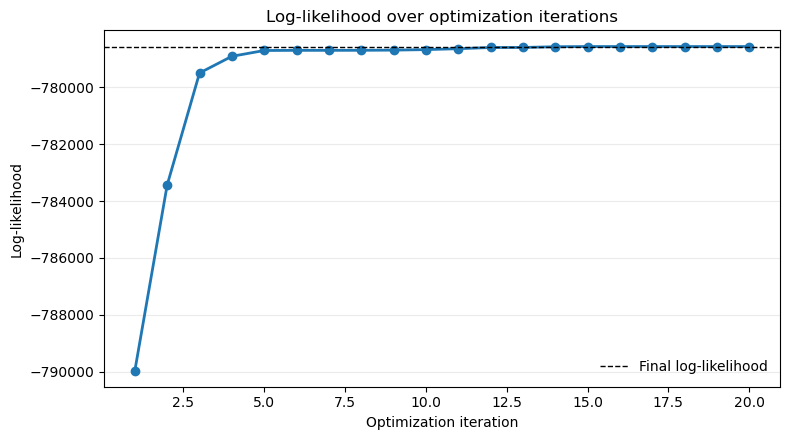

In [472]:
x0     = np.array(best_free)
bounds = [PARAM_BOUNDS[p] for p in FREE_PARAMS]

ll_iter_trace = []

def opt_callback(xk):
    ll_iter_trace.append(-neg_ll(xk))

t0 = time.perf_counter()
res = minimize(
    neg_ll,
    x0,
    method="L-BFGS-B",
    bounds=bounds,
    callback=opt_callback,
    options={"ftol": 1e-10, "gtol": 1e-7, "maxiter": 500},
)
elapsed = time.perf_counter() - t0

if not res.success:
    print(f"ADVARSEL: Optimizer rapporterer ikke konvergens: {res.message}")

# Uddrag fuld parametervektor
full_hat = full_param_vec(res.x)
ALPHA_1_HAT, ALPHA_2_HAT, GAMMA_HAT, BETA_DEP_HAT, BETA_SC_HAT = full_hat
LL_HAT = -float(res.fun)

# ── Detektér grænseestimater ──────────────────────────────────────────────────
BOUND_TOL = 1e-6
n_free    = len(FREE_PARAMS)
at_bound  = np.array([
    abs(res.x[i] - bounds[i][0]) < BOUND_TOL or
    abs(res.x[i] - bounds[i][1]) < BOUND_TOL
    for i in range(n_free)
])
interior  = [i for i in range(n_free) if not at_bound[i]]

if any(at_bound):
    bound_names = [FREE_PARAMS[i] for i in range(n_free) if at_bound[i]]
    print(f"INFO: {bound_names} er ved grænsen — SE udelades for disse")

# ── Numerisk Hessian — KUN over indre parametre (ikke ved grænse) ─────────────
h_step  = 1e-4
SE_free = np.full(n_free, np.nan)

if interior and np.all(np.isfinite(res.x)):
    n_int    = len(interior)
    hess_int = np.full((n_int, n_int), np.nan)
    for ii, pi in enumerate(interior):
        for jj, pj in enumerate(interior):
            ep = np.zeros(n_free); ep[pi] = h_step
            eq = np.zeros(n_free); eq[pj] = h_step
            f_pp = neg_ll(res.x + ep + eq)
            f_pm = neg_ll(res.x + ep - eq)
            f_mp = neg_ll(res.x - ep + eq)
            f_mm = neg_ll(res.x - ep - eq)
            if np.all(np.isfinite([f_pp, f_pm, f_mp, f_mm])):
                hess_int[ii, jj] = (f_pp - f_pm - f_mp + f_mm) / (4 * h_step**2)

    if np.all(np.isfinite(hess_int)):
        try:
            cov_int  = np.linalg.inv(hess_int)
            diag_int = np.diag(cov_int)
            if not np.all(np.isfinite(diag_int)) or np.any(diag_int < 0):
                print("INFO: Hessian ikke PD — bruger pseudo-invers")
                cov_int  = np.linalg.pinv(hess_int)
                diag_int = np.diag(cov_int)
            for ii, i in enumerate(interior):
                SE_free[i] = np.sqrt(max(float(diag_int[ii]), 0.0))
        except np.linalg.LinAlgError:
            print("ADVARSEL: Hessian er singulær — SE ikke tilgængelige")
    else:
        print("ADVARSEL: Hessian indeholder NaN — SE ikke tilgængelige")

SE_dict = {p: np.nan for p in ALL_PARAM_NAMES}
for i, name in enumerate(FREE_PARAMS):
    SE_dict[name] = float(SE_free[i])

SE_ALPHA_1  = SE_dict["alpha_1"]
SE_ALPHA_2  = SE_dict["alpha_2"]
SE_GAMMA    = SE_dict["gamma"]
SE_BETA_DEP = SE_dict["beta_dep"]
SE_BETA_SC  = SE_dict["beta_sc"]

# ── Resultatoversigt ──────────────────────────────────────────────────────────
def zstat(est, se): return est / se if np.isfinite(se) and se > 0 else np.nan
def pval(z):        return float(2 * norm.sf(abs(z))) if np.isfinite(z) else np.nan
def stars(p):
    if not np.isfinite(p): return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

free_idx = {name: i for i, name in enumerate(FREE_PARAMS)}
est_map  = dict(zip(ALL_PARAM_NAMES,
                    [ALPHA_1_HAT, ALPHA_2_HAT, GAMMA_HAT, BETA_DEP_HAT, BETA_SC_HAT]))

print(f"Konvergeret: {res.success}  |  Iterationer: {res.nit}  |  Tid: {elapsed:.1f}s")
print(f"\n{'='*67}")
print(f"  {'Parameter':<15} {'Estimat':>10} {'Std. fejl':>10} {'z':>8} {'p-værdi':>12}  ")
print(f"  {'-'*62}")
for name in ALL_PARAM_NAMES:
    est = est_map[name]
    if name in FIXED_PARAMS:
        print(f"  {name:<15} {est:>10.6f} {'—':>10} {'—':>8} {'—':>12}  [fast]")
    elif at_bound[free_idx[name]]:
        print(f"  {name:<15} {est:>10.6f} {'—':>10} {'—':>8} {'—':>12}  [grænse]")
    else:
        se = SE_dict[name]
        z  = zstat(est, se)
        p  = pval(z)
        print(f"  {name:<15} {est:>10.6f} {se:>10.6f} {z:>8.4f} {p:>10.4e}  {stars(p)}")
print(f"  {'-'*62}")
print(f"{'='*67}")
print(f"  Log-lik = {LL_HAT:.2f}  (N_obs = {N_OBS:,})")
print("  Signifikansniveauer: *** p<0.01  ** p<0.05  * p<0.1")

# ── Log-likelihood trace over outer optimizer iterations ───────────────────
if ll_iter_trace:
    ll_iter_trace = np.array(ll_iter_trace, dtype=float)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(
        np.arange(1, len(ll_iter_trace) + 1),
        ll_iter_trace,
        marker="o",
        lw=2,
        color="#1F77B4",
    )
    ax.axhline(LL_HAT, color="black", lw=1, ls="--", label="Final log-likelihood")
    ax.set_xlabel("Optimization iteration")
    ax.set_ylabel("Log-likelihood")
    ax.set_title("Log-likelihood over optimization iterations")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("nfxp_empirical_ll_optimization_trace.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Ingen optimizer-iterationer registreret i ll_iter_trace.")


## 9b. Likelihood-slices for frie parametre

Én parameter varieres ad gangen omkring estimatet, mens de øvrige holdes fast på MLE. Dette er en hurtig identifikationsdiagnostic, ikke en fuld profile likelihood med reoptimering.

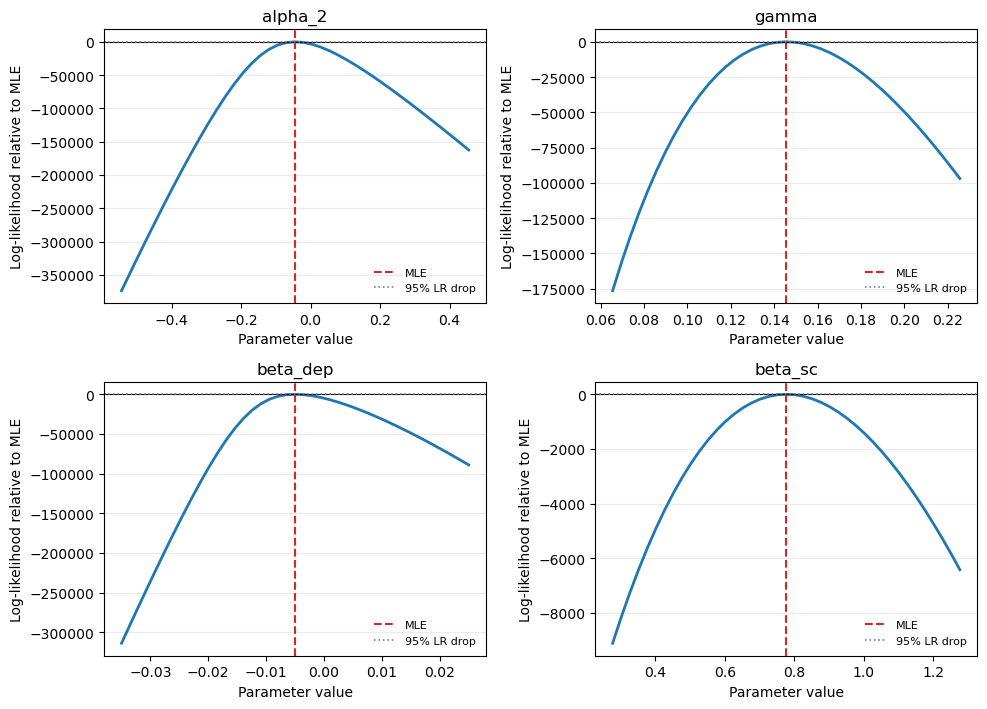

Likelihood-slices gemt i nfxp_empirical_likelihood_slices.pdf
Faste parametre uden likelihood-slice: ['alpha_1']


In [473]:
# ── 1D likelihood-slices omkring MLE ───────────────────────────────────────
SLICE_POINTS = 41
SLICE_WINDOWS = {
    "alpha_1": 0.50,
    "alpha_2": 0.50,
    "gamma": 0.08,
    "beta_dep": 0.03,
    "beta_sc": 0.50,
}

slice_results = {}
for i, pname in enumerate(FREE_PARAMS):
    est = float(res.x[i])
    lo, hi = PARAM_BOUNDS[pname]
    width = SLICE_WINDOWS.get(pname, 0.25 * max(abs(est), 1.0))
    grid_lo = max(lo, est - width)
    grid_hi = min(hi, est + width)

    if np.isclose(grid_lo, grid_hi):
        print(f"Springer {pname} over: for smalt grid omkring bound")
        continue

    grid = np.linspace(grid_lo, grid_hi, SLICE_POINTS)
    if not np.any(np.isclose(grid, est)):
        grid = np.sort(np.r_[grid, est])

    ll_vals = np.empty_like(grid, dtype=float)
    for k, val in enumerate(grid):
        trial = np.array(res.x, dtype=float)
        trial[i] = val
        ll_vals[k] = -neg_ll(trial)

    slice_results[pname] = pd.DataFrame({
        "param_value": grid,
        "log_likelihood": ll_vals,
        "delta_log_likelihood": ll_vals - LL_HAT,
    })

if slice_results:
    n_plots = len(slice_results)
    n_cols = 2
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.6 * n_rows), squeeze=False)
    axes_flat = axes.ravel()
    lr95_drop = -0.5 * chi2.ppf(0.95, df=1)

    for ax, (pname, frame) in zip(axes_flat, slice_results.items()):
        est = float(res.x[FREE_PARAMS.index(pname)])
        ax.plot(frame["param_value"], frame["delta_log_likelihood"], lw=2, color="#1F77B4")
        ax.axvline(est, color="#D62728", ls="--", lw=1.5, label="MLE")
        ax.axhline(0.0, color="black", lw=0.8)
        ax.axhline(lr95_drop, color="gray", ls=":", lw=1.2, label="95% LR drop")
        ax.set_title(pname)
        ax.set_xlabel("Parameter value")
        ax.set_ylabel("Log-likelihood relative to MLE")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(frameon=False, fontsize=8)

    for ax in axes_flat[n_plots:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("nfxp_empirical_likelihood_slices.pdf", bbox_inches="tight")
    plt.show()

    print("Likelihood-slices gemt i nfxp_empirical_likelihood_slices.pdf")
    if FIXED_PARAMS:
        print(f"Faste parametre uden likelihood-slice: {list(FIXED_PARAMS.keys())}")


## 10. Likelihood-kurve og estimat

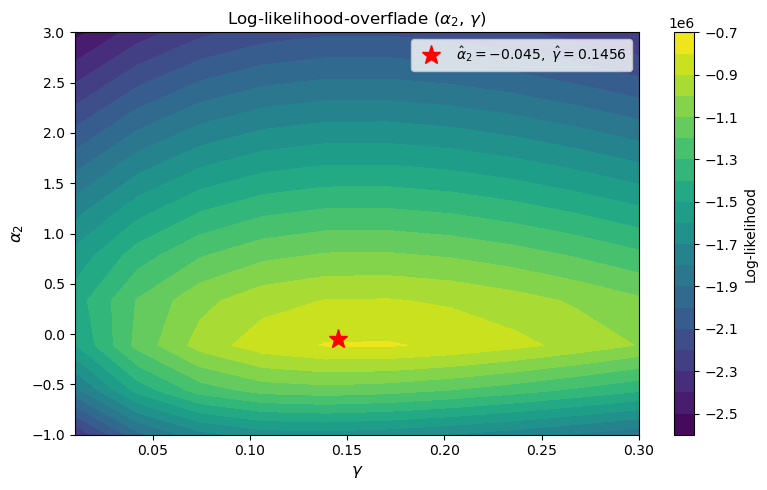


Observerede vs. forudsagte valgsandsynligheder:
     Valg  Observeret andel  Forudsagt andel  Forskel
Ingen køb            0.8479           0.8571   0.0092
  Brand 1            0.0337           0.0297  -0.0040
  Brand 2            0.1184           0.1132  -0.0053


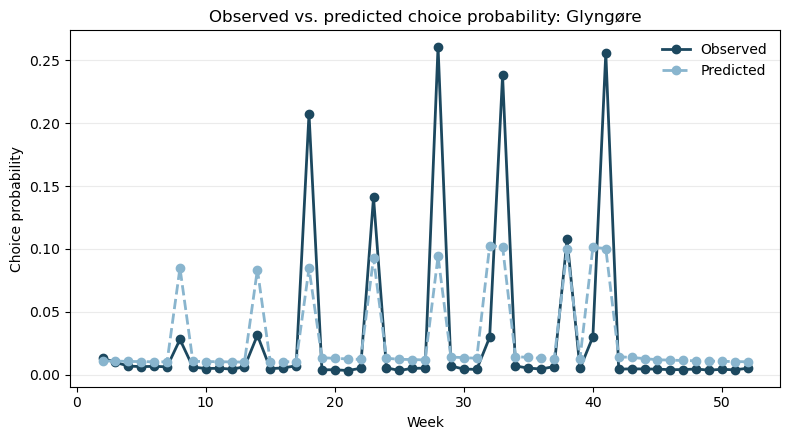

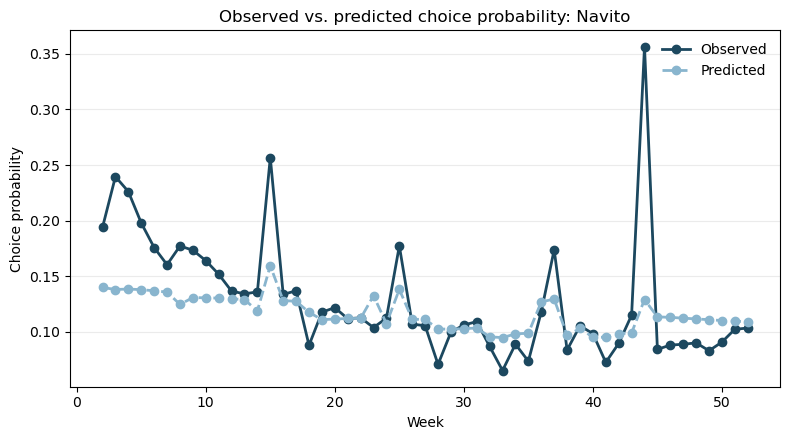

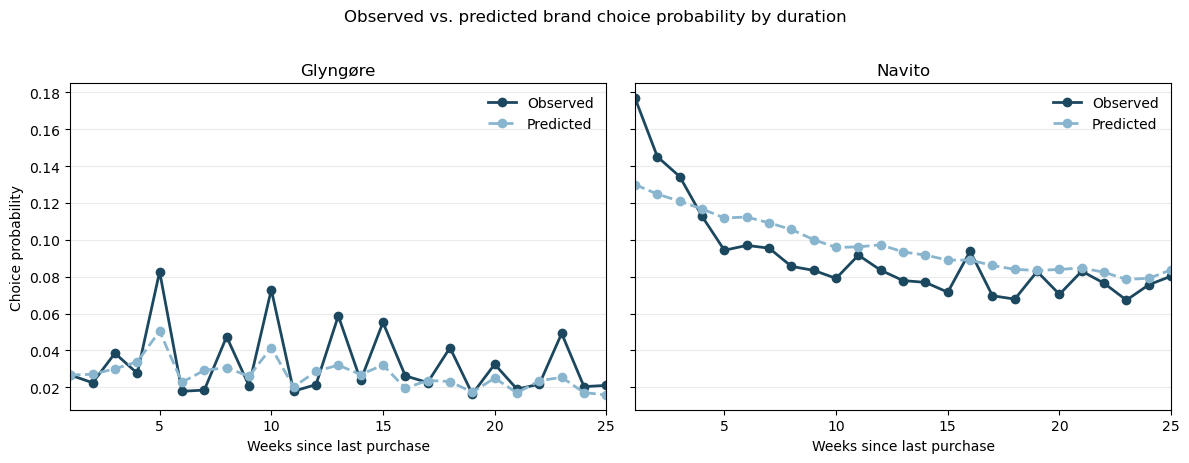

In [474]:
# ── Contour-plot over likelihood-overflade ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.contourf(GRID_GAM, GRID_A2, ll_grid2d, levels=20, cmap="viridis")
plt.colorbar(cf, ax=ax, label="Log-likelihood")
ax.plot(GAMMA_HAT, ALPHA_2_HAT, "r*", ms=14,
        label=rf"$\hat{{\alpha}}_2={ALPHA_2_HAT:.3f},\ \hat{{\gamma}}={GAMMA_HAT:.4f}$")
ax.set_xlabel(r"$\gamma$", fontsize=12)
ax.set_ylabel(r"$\alpha_2$", fontsize=12)
ax.set_title(r"Log-likelihood-overflade $(\alpha_2,\,\gamma)$", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("nfxp_empirical_joint.pdf", bbox_inches="tight")
plt.show()

# ── Tilpassede vs. observerede valgsandsynligheder ─────────────────────────
alpha_hat    = make_alpha(ALPHA_1_HAT, ALPHA_2_HAT)
beta_dep_hat = make_beta_dep(BETA_DEP_HAT)
beta_sc_hat  = make_beta_sc(BETA_SC_HAT)
V_hat = solve_vfi(alpha_hat, GAMMA_HAT, beta_sc_hat, beta_dep_hat)
P_hat = compute_ccps(V_hat, alpha_hat, GAMMA_HAT, beta_sc_hat, beta_dep_hat)

state_counts = OBS_COUNTS.sum(axis=3)
obs_shares   = OBS_COUNTS.sum(axis=(0, 1, 2)) / N_OBS
pred_shares  = (state_counts[..., None] * P_hat).sum(axis=(0, 1, 2)) / N_OBS

fit_table = pd.DataFrame({
    "Valg":               ["Ingen køb", "Brand 1", "Brand 2"],
    "Observeret andel":   obs_shares,
    "Forudsagt andel":    pred_shares,
    "Forskel":            pred_shares - obs_shares,
})
print("\nObserverede vs. forudsagte valgsandsynligheder:")
print(fit_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ── Brand-specifik observed vs. predicted over tid ─────────────────────────
panel_df["pred_glyngore_prob"] = P_hat[
    panel_df["L"].to_numpy(dtype=int) - 1,
    panel_df["D"].to_numpy(dtype=int),
    panel_df["E_IDX"].to_numpy(dtype=int),
    1,
]
panel_df["pred_navito_prob"] = P_hat[
    panel_df["L"].to_numpy(dtype=int) - 1,
    panel_df["D"].to_numpy(dtype=int),
    panel_df["E_IDX"].to_numpy(dtype=int),
    2,
]

panel_df["actual_glyngore"] = (panel_df["Y"] == 1).astype(int)
panel_df["actual_navito"] = (panel_df["Y"] == 2).astype(int)

weekly_brand_fit = (
    panel_df
    .groupby("week_num")
    .agg(
        actual_glyngore_prob=("actual_glyngore", "mean"),
        predicted_glyngore_prob=("pred_glyngore_prob", "mean"),
        actual_navito_prob=("actual_navito", "mean"),
        predicted_navito_prob=("pred_navito_prob", "mean"),
        obs=("Y", "size"),
    )
    .reset_index()
)

COLOR_OBS = "#1c485f"
COLOR_PRED = "#89b5ce"

# Glyngøre
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    weekly_brand_fit["week_num"],
    weekly_brand_fit["actual_glyngore_prob"],
    marker="o",
    lw=2,
    color=COLOR_OBS,
    label="Observed",
)
ax.plot(
    weekly_brand_fit["week_num"],
    weekly_brand_fit["predicted_glyngore_prob"],
    marker="o",
    lw=2,
    ls="--",
    color=COLOR_PRED,
    label="Predicted",
)
ax.set_xlabel("Week")
ax.set_ylabel("Choice probability")
ax.set_title("Observed vs. predicted choice probability: Glyngøre")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("nfxp_empirical_glyngore_fit_over_time.pdf", bbox_inches="tight")
plt.show()

# Navito
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    weekly_brand_fit["week_num"],
    weekly_brand_fit["actual_navito_prob"],
    marker="o",
    lw=2,
    color=COLOR_OBS,
    label="Observed",
)
ax.plot(
    weekly_brand_fit["week_num"],
    weekly_brand_fit["predicted_navito_prob"],
    marker="o",
    lw=2,
    ls="--",
    color=COLOR_PRED,
    label="Predicted",
)
ax.set_xlabel("Week")
ax.set_ylabel("Choice probability")
ax.set_title("Observed vs. predicted choice probability: Navito")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("nfxp_empirical_navito_fit_over_time.pdf", bbox_inches="tight")
plt.show()


# ── Brand-specific observed vs. predicted by duration ──────────────────────
duration_brand_fit = (
    panel_df
    .groupby("D")
    .agg(
        actual_glyngore_prob=("actual_glyngore", "mean"),
        predicted_glyngore_prob=("pred_glyngore_prob", "mean"),
        actual_navito_prob=("actual_navito", "mean"),
        predicted_navito_prob=("pred_navito_prob", "mean"),
        obs=("Y", "size"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

axes[0].plot(
    duration_brand_fit["D"],
    duration_brand_fit["actual_glyngore_prob"],
    marker="o",
    lw=2,
    color=COLOR_OBS,
    label="Observed",
)
axes[0].plot(
    duration_brand_fit["D"],
    duration_brand_fit["predicted_glyngore_prob"],
    marker="o",
    lw=2,
    ls="--",
    color=COLOR_PRED,
    label="Predicted",
)
axes[0].set_title("Glyngøre")
axes[0].set_xlabel("Weeks since last purchase")
axes[0].set_ylabel("Choice probability")
axes[0].set_xlim(1, D_MAX)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(
    duration_brand_fit["D"],
    duration_brand_fit["actual_navito_prob"],
    marker="o",
    lw=2,
    color=COLOR_OBS,
    label="Observed",
)
axes[1].plot(
    duration_brand_fit["D"],
    duration_brand_fit["predicted_navito_prob"],
    marker="o",
    lw=2,
    ls="--",
    color=COLOR_PRED,
    label="Predicted",
)
axes[1].set_title("Navito")
axes[1].set_xlabel("Weeks since last purchase")
axes[1].set_xlim(1, D_MAX)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(frameon=False)

fig.suptitle("Observed vs. predicted brand choice probability by duration", y=1.02)
plt.tight_layout()
plt.savefig("nfxp_empirical_brand_fit_by_duration.pdf", bbox_inches="tight")
plt.show()
